# GeoSlip2D profile slip inversion activities

You will use this notebook to conduct 1D profile slip inversions of your data set(s) generated on Day 1 of this course.

## Learning goals
- Build Green's functions for a selected Earth model (`homogeneous`, `layered`, `wedge`, or `vecycle`).
- Project map-view velocity data onto a 1D profile.
- Solve a regularized slip inversion with configurable bounds and solver options.
- Interpret model fit, residuals, and recovered slip.

## Workflow overview
1. Configure inversion options and load data set.
2. Load and project lon/lat velocity data to a profile.
3. Build and save/reload Green's functions for a selected operator.
4. Solve the inversion and visualize fits and slip.

## Data format

There are two supported input data layouts. Set `data_format` to either `"default"` or `"alternate"`; the notebook checks that this matches the file structure.

Default format columns:

```text
lon, lat, Ve, Vn, Vu, Sige, Sign, Sigu
```

Alternate format columns:

```text
station, lat, lon, Ve, Ve_sig, Vn, Vn_sig, Vu, Vu_sig, Ve_pred, Vn_pred, n_obs
```

## Suggested run order
- Run all cells once from top to bottom.
- If you change dataset or inversion settings, rerun from Section 1 onward.
- If you change interface/Green's-function settings, rerun from Section 4 onward.

In [1]:
# import standard libraries and helper functions
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np

import geoslip2d as gs2d
from geoslip2d.inversion import (
    filter_profile_data,
    observations_from_projected_profile,
    save_inversion_result,
)

# Always reload local helper module so notebook uses latest edits.
import geoslip2d.data_format_helpers as dfh
importlib.reload(dfh)
from geoslip2d.data_format_helpers import load_profile_data_with_format

# Resolve project/data/output directories.
PROJECT_ROOT = Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = PROJECT_ROOT / "data"

print(f"Using PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Reading data from {DATA_DIR}")
print(f"Writing outputs to {OUTPUT_DIR}")

from geoslip2d.notebook_helpers import (
    make_synthetic_observations,
    patch_center_depths,
    patch_center_x,
    plot_inversion_results,
    plot_surface_velocities,
    run_pair_inversions,
    surface_velocity,
    uniform_backslip_above_depth,
)


Using PROJECT_ROOT = /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D_development/2026_Geodesy_TSC/notebooks/Day3
Reading data from /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D_development/2026_Geodesy_TSC/notebooks/Day3/data
Writing outputs to /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D_development/2026_Geodesy_TSC/notebooks/Day3/outputs


## 1. Choose and load dataset 

Provide name of data file which should normally be located in the "data" direction, DATA_DIR = PROJECT_ROOT / "data". 

In [20]:
# Load data set and specify format.

#data_filename = DATA_DIR / "synthetic_data.txt"
#data_filename = DATA_DIR / "gnss_interseismic_velocities_NAfixed.txt"
data_filename = DATA_DIR / "Lindsey_velocities_NAfixed_corrected.txt"

data_format = "default"  # choose "default" or "alternate"

# Baseline data settings.
# Keep use_vertical/data_has_vertical synchronized with the selected dataset.
inversion_cfg = gs2d.SlipInversionConfig(
    use_vertical=False,
    data_has_vertical=False,
    save_results=True,
)

data_raw, detected_format = load_profile_data_with_format(
    data_filename,
    data_format,
    data_has_vertical=inversion_cfg.data_has_vertical,
)

print(f"Data file: {data_filename}")
print(f"Configured format: {data_format}")
print(f"Detected format:   {detected_format}")
print(f"use_vertical:      {inversion_cfg.use_vertical}")
print(f"data_has_vertical: {inversion_cfg.data_has_vertical}")

Data file: /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D_development/2026_Geodesy_TSC/notebooks/Day3/data/Lindsey_velocities_NAfixed_corrected.txt
Configured format: default
Detected format:   default
use_vertical:      False
data_has_vertical: False


## 2. Load data and project to the profile

Load velocity data, filter invalid rows, project selected vectors to the profile, and create `ProfileObservations` for inversion.

In [40]:
# Load, filter, and project the data,
# then extract the profile-parallel component of the projected displacements
# as observations for inversion.


# Define the map/profile geometry used to project 2-D GNSS vectors onto a 1-D transect.
projection_cfg = gs2d.ProfileProjectionConfig(
    #endpoints=(-120.0, 45.0, -116.0, 44.09), # Define the endpoints of the profile in (lon1, lat1, lon2, lat2).
    endpoints=(-126.0, 46.0, -120, 47), # Define the endpoints of the profile in (lon1, lat1, lon2, lat2).
    project_dist=50.0,  # Distance over which to project data points onto the profile.
    #trench_llh=(-120.0, 45.0),  # Location of the trench in (lon, lat, height).
    trench_llh=(-126.0, 46.0),  # Location of the trench in (lon, lat, height).
    horizontal_component="profile_parallel",  # Component of horizontal displacement to use.
)

# Use the format-aware data loaded in Section 1.
if "data_raw" not in globals():
    raise RuntimeError("Run Section 1 first to load data_raw with load_profile_data_with_format.")

data, good_mask_original = filter_profile_data(data_raw, use_vertical=inversion_cfg.use_vertical)
profile = gs2d.project_data_to_profile(data, projection_cfg, use_vertical=inversion_cfg.use_vertical)
observations = observations_from_projected_profile(profile, use_vertical=inversion_cfg.use_vertical)

print(f"Number of original data rows: {data_raw['lon'].size}")
print(f"Number of retained data rows: {data['lon'].size}")
print(f"Number of data within profile swath: {observations.x_hor.size}")
print(f"Profile x range: {observations.x_hor.min():.2f} to {observations.x_hor.max():.2f} km")
print(f"Perpendicular distance range: {profile['perp_dist'][profile['in_profile']].min():.2f} to {profile['perp_dist'][profile['in_profile']].max():.2f} km")

Number of original data rows: 639
Number of retained data rows: 639
Number of data within profile swath: 83
Profile x range: 151.90 to 453.83 km
Perpendicular distance range: -49.75 to 48.33 km


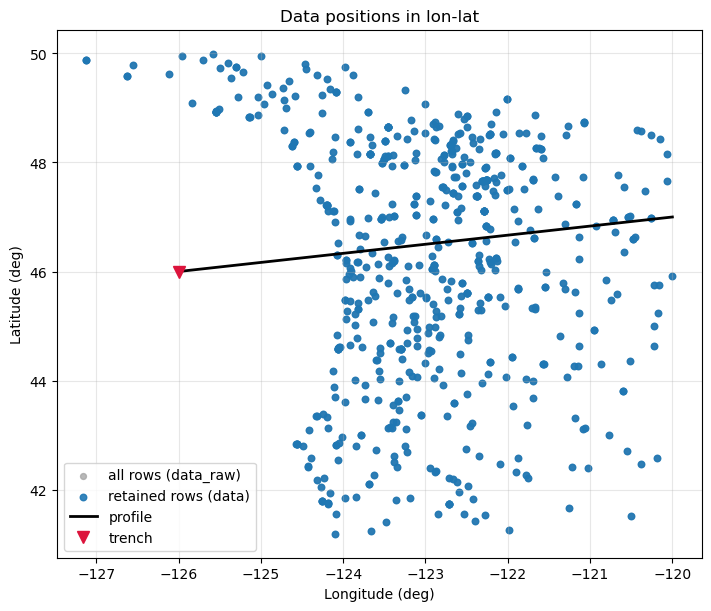

In [41]:
# Quick map of station positions in geographic coordinates (lon, lat),
# with profile transect and trench location overlaid.
lon = np.asarray(data_raw["lon"], dtype=float)
lat = np.asarray(data_raw["lat"], dtype=float)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.scatter(lon, lat, s=18, c="0.65", alpha=0.8, label="all rows (data_raw)")

# Overlay retained/filtered rows if available.
if "data" in globals() and isinstance(data, dict) and "lon" in data and "lat" in data:
    ax.scatter(
        np.asarray(data["lon"], dtype=float),
        np.asarray(data["lat"], dtype=float),
        s=22,
        c="tab:blue",
        alpha=0.9,
        label="retained rows (data)",
    )

# Overlay profile line and trench location from projection settings.
if "projection_cfg" in globals():
    lon1, lat1, lon2, lat2 = projection_cfg.endpoints
    ax.plot([lon1, lon2], [lat1, lat2], "k-", linewidth=2, label="profile")

    trench_lon, trench_lat = projection_cfg.trench_llh[:2]
    ax.plot(
        trench_lon,
        trench_lat,
        marker="v",
        color="crimson",
        markersize=9,
        linestyle="None",
        label="trench",
    )

ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Latitude (deg)")
ax.set_title("Data positions in lon-lat")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()

## 3. Plot map-view data selection

Use this plot to verify that the profile swath and selected vectors are consistent with your intended transect.

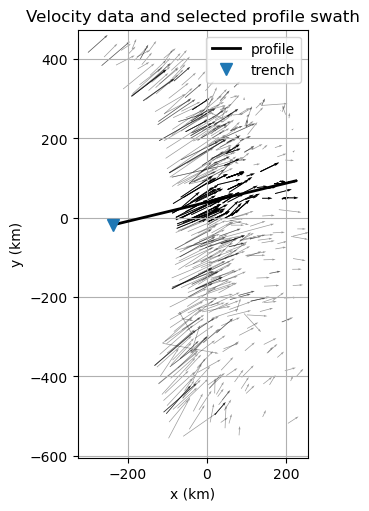

In [42]:


# Visualize the data and the profile swath to confirm that the projection 
# and selection of data points is as expected.
xy = profile["xy_gps"]
in_profile = profile["in_profile"]

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax.quiver(
    xy[:, 0], xy[:, 1], data["Ve"], data["Vn"],
    angles="xy", scale_units="xy", scale=.1, width=0.003, alpha=0.4,
)
ax.quiver(
    xy[in_profile, 0], xy[in_profile, 1],
    data["Ve"][in_profile], data["Vn"][in_profile],
    angles="xy", scale_units="xy", scale=.1, width=0.004,
)
ax.plot(profile["xy_endpoints"][:, 0], profile["xy_endpoints"][:, 1], "k-", linewidth=2, label="profile")
ax.plot(profile["xy_trench"][0], profile["xy_trench"][1], "v", markersize=8, label="trench")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Velocity data and selected profile swath")
ax.legend()
plt.show()

## 4. Build Green's functions (choose operator)

Build interface geometry and choose one Green's-function operator:
- `homogeneous`
- `layered`
- `wedge` (compliant wedge)
- `vecycle` (viscoelastic cycle)

![Interface Geometry](./images/interface_geometry.png)

Built operator: homogeneous
InterfaceGeometry(n_patch=52, x=[0, 251] km, z=[-0, 65.5] km)
Greens2D(source_type='homogeneous', n_obs=300, n_patch=52, has_vertical=True, units='displacement_per_unit_slip')


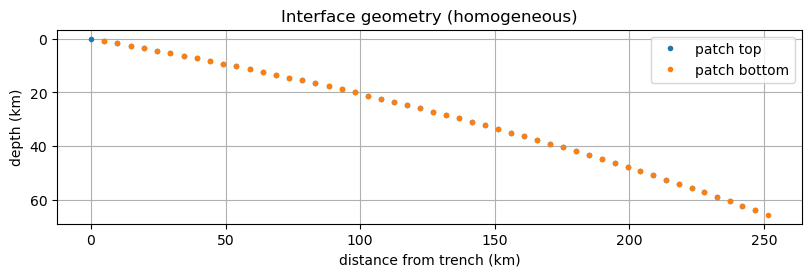

In [51]:
# Build interface geometry shared by all operator choices.
interface = gs2d.make_interface_geometry_legacy(
    faultdip_trench=10.0,  # dip at trench (degrees)
    x_trench=0.0,
    x_bottom=250.0,
    faultdip_bottom=20.0,  # dip at base (degrees)
    z_bottom=65.0,
    patch_length=5.0,
)

# Observation coordinates (km) where Green's functions are evaluated.
xobs = np.linspace(0.5, 500.0, 300)

# Choose Green's operator to build.
# Options: "homogeneous", "layered", "wedge", "vecycle"
GREENS_METHOD = "homogeneous"

if GREENS_METHOD == "homogeneous":
    greens = gs2d.build_greens(
        "homogeneous",
        interface,
        xobs,
        gs2d.HomogeneousConfig(length_override=5.0),
    )

elif GREENS_METHOD == "layered":
    layered_cfg = gs2d.LayeredConfig(
        h=np.array([5.0, 10.0, 15.0]),
        mu=np.array([1.0, 3.0, 5.0, 10.0]),
        nu=np.array([0.25, 0.25, 0.25, 0.25]),
        progress=True,
    )
    greens = gs2d.build_greens("layered", interface, xobs, layered_cfg)

elif GREENS_METHOD == "wedge":
    wedge_cfg = gs2d.WedgeConfig(
        wedge_bot=12.0,
        wedge_top_x=90.0,
        L_slab=50.0,
        W=200.0,
        mu1=1.0,
        mu2=0.1,
        mu3=10.0,
        nu=0.25,
        sync_geometry_from_interface=True,
        progress=True,
    )
    greens = gs2d.build_greens("wedge", interface, xobs, wedge_cfg)

elif GREENS_METHOD == "vecycle":
    vecycle_cfg = gs2d.VECycleConfig(
        mode="build",
        component="interseismic",
        progress=True,
        config_overrides={
            "geometry.faultdip_trench": 10.0,
            "geometry.faultdip_bottom": 20.0,
            "geometry.x_trench": 0.0,
            "geometry.x_bottom": 250.0,
            "geometry.wedge_bot": 65.0,
            "geometry.pL": 5.0,
            "geometry.wedge_top_x": 250.0,
            "geometry.L_slab": 500.0,
        },
    )
    greens = gs2d.build_greens("vecycle", interface, xobs, vecycle_cfg)

else:
    raise ValueError("GREENS_METHOD must be one of: homogeneous, layered, wedge, vecycle")

print(f"Built operator: {GREENS_METHOD}")
print(interface.summary())
print(greens.summary())

fig = gs2d.plot_interface(interface)
ax = fig.axes[0]
ax.set_title(f"Interface geometry ({GREENS_METHOD})")
plt.show()

## 5. Save and reload Green's functions

Save Green's functions to disk and reload them to demonstrate reproducible I/O and downstream reuse.

In [48]:
greens_file = OUTPUT_DIR / f"Greens_{GREENS_METHOD}_synthetic_profile.npz"
gs2d.save_greens(greens_file, greens)
greens = gs2d.load_greens(greens_file)

print(f"Saved/reloaded: {greens_file}")
print(greens.summary())

Saved/reloaded: /Users/kajjohns/Library/CloudStorage/OneDrive-IndianaUniversity/FromGoogle/files/Release/GeoSlip2D_development/2026_Geodesy_TSC/notebooks/Day3/outputs/Greens_wedge_synthetic_profile.npz
Greens2D(source_type='wedge', n_obs=300, n_patch=61, has_vertical=True, units='displacement_per_unit_slip')


## 6. Solve the slip inversion

Solve for profile slip using the configured regularization, solver, and inversion mode.

In [54]:
# Inversion settings.
# The dataset-specific inversion_mode is set below to keep them synchronized.
inversion_cfg = gs2d.SlipInversionConfig(
    alpha=1.0,
    smoothing_order="second",  # "first", "second", or "none"
    use_vertical=False,
    data_has_vertical=False,
    inversion_mode="slip_deficit",  # "forward_slip" or "slip_deficit"
    solver_type="nonnegative",  # "unbounded", "nonnegative", or "bounded"
    lower_bound=0.0,
    upper_bound=np.inf,
    save_results=True,
)


# Perform the profile slip inversion using GeoSlip2D.
result = gs2d.fit_profile_slip(observations, greens, inversion_cfg)

print("Profile slip inversion complete.")
print(f"  Number of horizontal data: {observations.x_hor.size}")
print(f"  Number of vertical data:   {observations.x_vert.size if observations.has_vertical else 0}")
print(f"  Number of model elements:  {greens.n_patch}")
print(f"  Inversion mode:            {inversion_cfg.inversion_mode}")
print(f"  Smoothing order:           {inversion_cfg.smoothing_order}")
print(f"  Solver type:               {inversion_cfg.solver_type}")
print(f"  Weighted RMS residual:     {result['wrms']:.3f}")
print(f"  Model roughness:           {result['roughness']:.3g}")

if inversion_cfg.save_results:
    save_inversion_result(inversion_cfg.results_filename, result)
    print(f"Saved result file: {inversion_cfg.results_filename}")

Profile slip inversion complete.
  Number of horizontal data: 83
  Number of vertical data:   0
  Number of model elements:  52
  Inversion mode:            slip_deficit
  Smoothing order:           second
  Solver type:               nonnegative
  Weighted RMS residual:     1.820
  Model roughness:           2.42
Saved result file: profile_slip_inversion_results.mat


## 7. Plot fits and recovered slip

Plot horizontal/vertical fits, residuals, and the recovered slip distribution for interpretation and quality control.

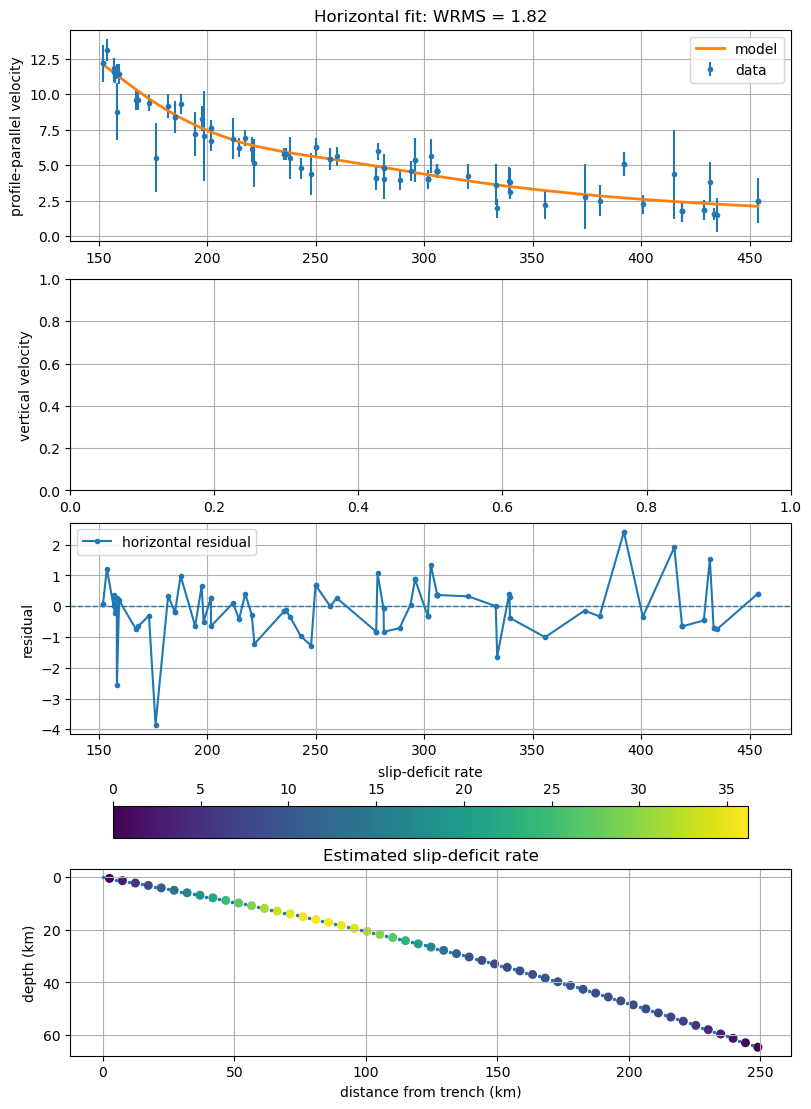

In [55]:
# Visualize the data fit, residuals, and estimated slip distribution.

# Sort the data by location for plotting.
order_h = np.argsort(observations.x_hor)
order_v = np.argsort(observations.x_vert) if observations.has_vertical else None
centers_x = greens.interface.centers[:, 0]
centers_z = greens.interface.centers[:, 1]

# Vertical model arrays are empty when inversion_cfg.use_vertical is False.
has_vertical_model = (
    observations.has_vertical
    and np.size(result.get("dhat_vert", np.array([]))) == observations.x_vert.size
    and np.size(result.get("residual_vert", np.array([]))) == observations.x_vert.size
)

fig, axes = plt.subplots(4, 1, figsize=(8, 11), constrained_layout=True)

ax = axes[0]
ax.errorbar(observations.x_hor, observations.v_hor, yerr=2 * observations.sig_hor, fmt=".", label="data")
ax.plot(observations.x_hor[order_h], result["dhat_hor"][order_h], linewidth=2, label="model")
ax.set_ylabel(profile.get("horizontal_label", "horizontal velocity"))
ax.set_title(f"Horizontal fit: WRMS = {np.sqrt(np.mean((result['residual_hor'] / observations.sig_hor) ** 2)):.2f}")
ax.grid(True)
ax.legend()

ax = axes[1]
if observations.has_vertical:
    ax.errorbar(observations.x_vert, observations.v_vert, yerr=2 * observations.sig_vert, fmt=".", label="data")
if has_vertical_model:
    ax.plot(observations.x_vert[order_v], result["dhat_vert"][order_v], linewidth=2, label="model")
    ax.set_title(f"Vertical fit: WRMS = {np.sqrt(np.mean((result['residual_vert'] / observations.sig_vert) ** 2)):.2f}")
    ax.legend()
elif observations.has_vertical:
    ax.set_title("Vertical data shown (not used in inversion model fit)")
    ax.legend()
ax.set_ylabel("vertical velocity")
ax.grid(True)

ax = axes[2]
ax.plot(observations.x_hor[order_h], result["residual_hor"][order_h], ".-", label="horizontal residual")
if has_vertical_model:
    ax.plot(observations.x_vert[order_v], result["residual_vert"][order_v], ".-", label="vertical residual")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_ylabel("residual")
ax.grid(True)
ax.legend()

ax = axes[3]
sc = ax.scatter(centers_x, centers_z, c=result["slip_hat"], s=30)
ax.plot(greens.interface.topx, greens.interface.topz, ".", markersize=3)
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.grid(True)
ax.set_xlabel("distance from trench (km)")
ax.set_ylabel("depth (km)")
ax.set_title(f"Estimated {result['model_label']}")
cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", location="top")
cbar.set_label(result["model_label"])

plt.show()